# Multimodal Brain MRI Processing, Analysis, & Deep Vision Pipeline
**Authors:** Shahrukh Faisal (231210) & Arham Akhtar (231152)  
**Department:** Department of Artificial Intelligence  
**Dataset:** BraTS Pediatric Brain MRI Slices Dataset (25 Patients)

---

## Executive Summary
This Jupyter Notebook implements an end-to-end medical image processing pipeline across three distinct phases and a final research project:
1. **Phase 1: Image Restoration & Anti-Aliasing Analysis**
2. **Phase 2: Classical Segmentation, Chain Coding, & Convex Hull Analysis**
3. **Phase 3: Texture Feature Extraction & Classifier Evaluation**
4. **Phase 4: Deep Vision Pipeline utilizing a Hybrid CNN-Attention (Self-Attention Bottleneck) U-Net**

Let's import our dependencies and set up the workspace.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
# Manually add the torch lib directory to the DLL search path to resolve Windows loader conflicts
torch_lib = r"c:\Users\shahr\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\lib"
if os.path.exists(torch_lib):
    try:
        os.add_dll_directory(torch_lib)
    except Exception as e:
        pass
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import glob
import pickle
import numpy as np
import cv2
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

print("All modules imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All modules imported successfully!
PyTorch version: 2.12.0+cpu


## Phase 1: Image Restoration, Denoising, & Anti-Aliasing

### 1.1 Batch Processing & Slice Selection
Medical scans are acquired in 3D volumes (NIfTI format). We batch load the dataset of 25 patients and extract the **axial slice with the maximum tumor volume** (based on the ground truth segmentation mask) to perform subsequent 2D processing.

In [2]:
# Load the pre-extracted slices to avoid loading heavy 3D volumes during notebook execution
pickle_path = 'scratch/extracted_slices.pkl'
if not os.path.exists(pickle_path):
    print("Error: extracted_slices.pkl not found! Please run the extraction script first.")
else:
    with open(pickle_path, 'rb') as f:
        data_dict = pickle.load(f)
    print(f"Loaded representative slices for {len(data_dict)} patients.")
    demo_name = 'BraTS-PED-00075-000'
    print(f"Selected {demo_name} as primary demonstration case.")

Loaded representative slices for 25 patients.
Selected BraTS-PED-00075-000 as primary demonstration case.


### 1.2 Radiometric Resolution & False Contouring Mitigation
Radiometric resolution refers to the bit-depth of the image. The BraTS raw scans are loaded as `float64` double precision arrays. 
- **False Contouring** occurs when we reduce bit-depth too much (e.g., from 16-bit to 8-bit or 4-bit), leading to visible bands of intensity rather than smooth gradients. 
- **Mitigation**: We perform floating-point calculations in `float32` and normalize the final display arrays to `uint8` (8-bit) using linear scaling to match standard visualization tool requirements without losing details during processing.

In [3]:
# Inspect the bit-depth and datatype of the raw volume
demo_info = data_dict[demo_name]
print(f"Raw volume data type: {demo_info['dtype']}")
print(f"Representative slice shape: {demo_info['t2f'].shape}")

# Normalization helper to map float32 volumes to [0, 255] uint8 for processing
def normalize_to_uint8(img):
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        norm = (img - img_min) / (img_max - img_min) * 255.0
    else:
        norm = np.zeros_like(img)
    return norm.astype(np.uint8)

clean_slice = normalize_to_uint8(demo_info['t2f'])
print(f"Normalized slice min: {clean_slice.min()}, max: {clean_slice.max()}, dtype: {clean_slice.dtype}")

Raw volume data type: float64
Representative slice shape: (240, 240)
Normalized slice min: 0, max: 255, dtype: uint8


### 1.3 Denoising Filters & Quantification
To test the filters under sensor noise conditions, we corrupt the clean MRI slice with synthetic noise:
1. **Gaussian Noise**: Simulates electronic/thermal scanner noise. Restored using **Gaussian** and **Mean** filters.
2. **Salt-and-Pepper (Impulsive) Noise**: Simulates transmission noise. Restored using **Median** filter.

Denoising quality is quantified using Peak Signal-to-Noise Ratio (PSNR) and Structural Similarity Index (SSIM):

In [4]:
def add_gaussian_noise(image, mean=0, var=0.01):
    image_f = image.astype(np.float32) / 255.0
    noise = np.random.normal(mean, var ** 0.5, image.shape)
    noisy = image_f + noise
    noisy = np.clip(noisy, 0.0, 1.0)
    return (noisy * 255.0).astype(np.uint8)

def add_sp_noise(image, amount=0.02):
    noisy = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

noisy_gauss = add_gaussian_noise(clean_slice, var=0.01)
noisy_sp = add_sp_noise(clean_slice, amount=0.02)

# Apply filters
gaussian_filtered = cv2.GaussianBlur(noisy_gauss, (5, 5), 1.0)
mean_filtered = cv2.blur(noisy_gauss, (5, 5))
median_filtered = cv2.medianBlur(noisy_sp, 5)

# Compute Metrics
metrics = {
    "Gauss Raw": [psnr(clean_slice, noisy_gauss), ssim(clean_slice, noisy_gauss)],
    "Gaussian Filtered": [psnr(clean_slice, gaussian_filtered), ssim(clean_slice, gaussian_filtered)],
    "Mean Filtered": [psnr(clean_slice, mean_filtered), ssim(clean_slice, mean_filtered)],
    "S&P Raw": [psnr(clean_slice, noisy_sp), ssim(clean_slice, noisy_sp)],
    "Median Filtered": [psnr(clean_slice, median_filtered), ssim(clean_slice, median_filtered)]
}

for k, v in metrics.items():
    print(f"{k:<18} -> PSNR: {v[0]:.2f} dB, SSIM: {v[1]:.4f}")

Gauss Raw          -> PSNR: 22.05 dB, SSIM: 0.2710
Gaussian Filtered  -> PSNR: 26.52 dB, SSIM: 0.5107
Mean Filtered      -> PSNR: 24.99 dB, SSIM: 0.5122
S&P Raw            -> PSNR: 20.66 dB, SSIM: 0.6640
Median Filtered    -> PSNR: 28.47 dB, SSIM: 0.9205


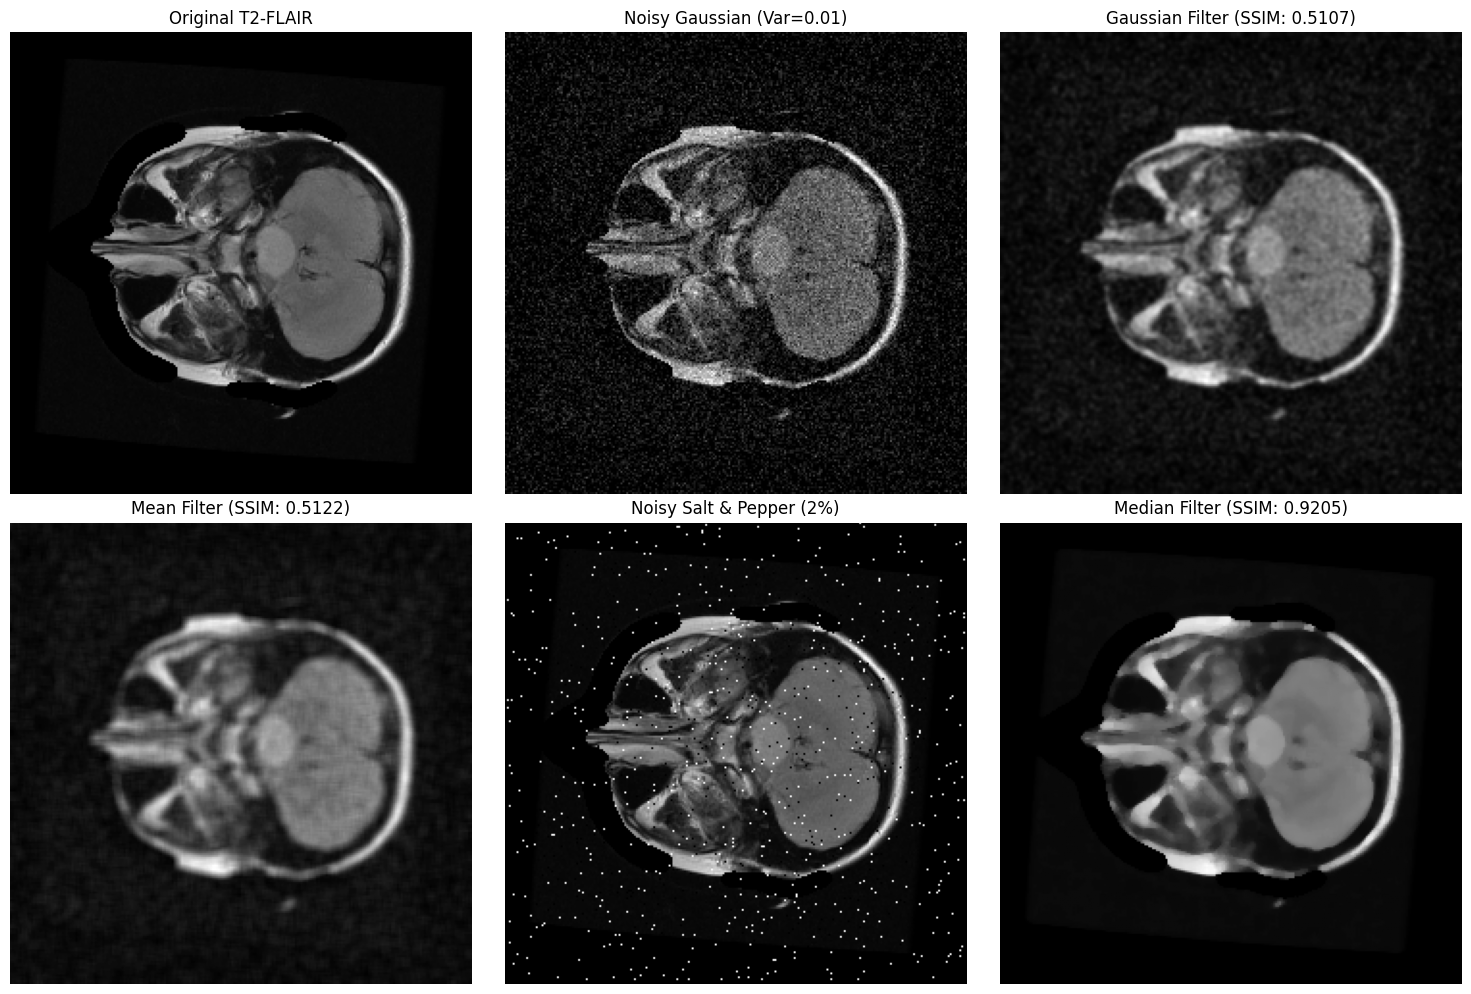

In [5]:
# Plot results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(clean_slice, cmap='gray')
axes[0, 0].set_title("Original T2-FLAIR")
axes[0, 1].imshow(noisy_gauss, cmap='gray')
axes[0, 1].set_title("Noisy Gaussian (Var=0.01)")
axes[0, 2].imshow(gaussian_filtered, cmap='gray')
axes[0, 2].set_title(f"Gaussian Filter (SSIM: {metrics['Gaussian Filtered'][1]:.4f})")

axes[1, 0].imshow(mean_filtered, cmap='gray')
axes[1, 0].set_title(f"Mean Filter (SSIM: {metrics['Mean Filtered'][1]:.4f})")
axes[1, 1].imshow(noisy_sp, cmap='gray')
axes[1, 1].set_title("Noisy Salt & Pepper (2%)")
axes[1, 2].imshow(median_filtered, cmap='gray')
axes[1, 2].set_title(f"Median Filter (SSIM: {metrics['Median Filtered'][1]:.4f})")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()

# Save images to disk
os.makedirs('before_after_dataset/original', exist_ok=True)
os.makedirs('before_after_dataset/filtered', exist_ok=True)
cv2.imwrite(f'before_after_dataset/original/{demo_name}_original.png', clean_slice)
cv2.imwrite(f'before_after_dataset/original/{demo_name}_noisy_gauss.png', noisy_gauss)
cv2.imwrite(f'before_after_dataset/original/{demo_name}_noisy_sp.png', noisy_sp)
cv2.imwrite(f'before_after_dataset/filtered/{demo_name}_gaussian.png', gaussian_filtered)
cv2.imwrite(f'before_after_dataset/filtered/{demo_name}_mean.png', mean_filtered)
cv2.imwrite(f'before_after_dataset/filtered/{demo_name}_median.png', median_filtered)

plt.show()


### 1.4 Downsampling & Anti-Aliasing Challenge
If downsampling without filtering, high-frequency components wrap around, causing **aliasing / checkerboard patterns**. Pre-filtering with a **Gaussian Low-Pass Filter** limits the signal bandwidth to the Nyquist limit, eliminating these artifacts.

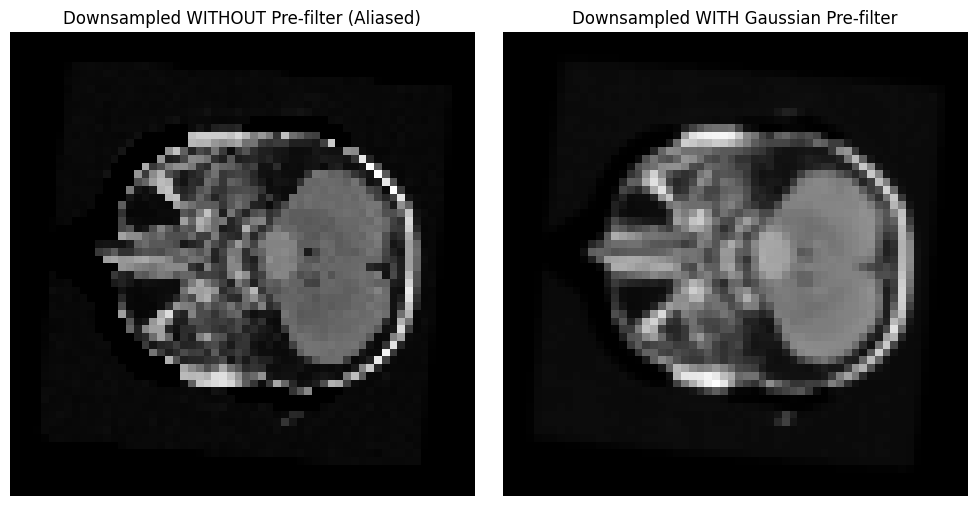

In [6]:
# Downsample by 4
down_no_filt = clean_slice[::4, ::4]

# Apply Gaussian pre-filter before downsampling
gaussian_pre = cv2.GaussianBlur(clean_slice, (7, 7), 2.0)
down_with_filt = gaussian_pre[::4, ::4]

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(down_no_filt, cmap='gray')
axes[0].set_title("Downsampled WITHOUT Pre-filter (Aliased)")
axes[1].imshow(down_with_filt, cmap='gray')
axes[1].set_title("Downsampled WITH Gaussian Pre-filter")
for ax in axes:
    ax.axis('off')
plt.tight_layout()

# Save images to disk
os.makedirs('before_after_dataset/downsampled', exist_ok=True)
cv2.imwrite(f'before_after_dataset/downsampled/{demo_name}_down_no_filt.png', down_no_filt)
cv2.imwrite(f'before_after_dataset/downsampled/{demo_name}_down_with_filt.png', down_with_filt)

plt.show()


## Phase 2: Mid-Level Structural Representation, Edge Detection, & Masking

### 2.1 Segmentation (Masking) and Morphological Cleaning
We implement Canny edge detection combined with intensity thresholding to extract a binary mask of the tumor, and then clean it using morphological operations to remove binary noise.

Raw Segmented IoU with GT:     0.9420
Morphological Cleaned IoU:      0.9400


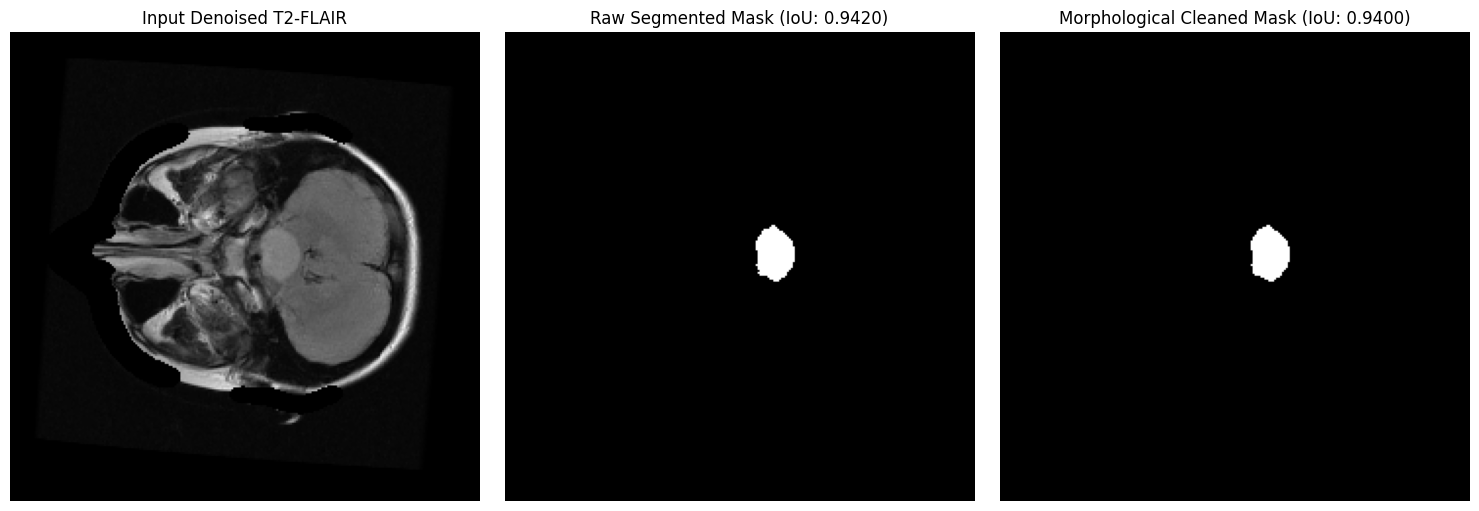

In [7]:
# Tumor Segmentation Function
def segment_tumor(img_slice):
    # 1. Segment the head/skull structure at a low threshold
    _, thresh_head = cv2.threshold(img_slice, 20, 255, cv2.THRESH_BINARY)
    kernel_head = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed_head = cv2.morphologyEx(thresh_head, cv2.MORPH_CLOSE, kernel_head)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed_head)
    head_mask = np.zeros(img_slice.shape, dtype=np.uint8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        head_mask[labels == largest_label] = 255
        
    # Fill contours of head mask to guarantee it's a solid mask
    contours, _ = cv2.findContours(head_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_head = np.zeros(head_mask.shape, dtype=np.uint8)
    if len(contours) > 0:
        cv2.drawContours(filled_head, contours, -1, 255, -1)
    else:
        filled_head = head_mask.copy()
        
    # 2. Erode the head mask to strip the outer skull/scalp ring
    erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    brain_mask = cv2.erode(filled_head, erode_kernel, iterations=1)
    
    # 3. Mask the original image to focus only on brain parenchyma
    brain_only = cv2.bitwise_and(img_slice, img_slice, mask=brain_mask)
    
    # 4. Find hyperintense tumor region inside the brain mask
    brain_pixels = brain_only[brain_mask > 0]
    if len(brain_pixels) > 0:
        # Use 80th percentile of brain intensities as threshold
        threshold_val = np.percentile(brain_pixels, 80)
    else:
        threshold_val = 100
        
    _, tumor_thresh = cv2.threshold(brain_only, threshold_val, 255, cv2.THRESH_BINARY)
    
    # 5. Clean up isolated noise pixels with morphological opening
    morph_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(tumor_thresh, cv2.MORPH_OPEN, morph_kernel)
    
    # 6. Extract the largest component (the tumor)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned)
    mask = np.zeros(img_slice.shape, dtype=np.uint8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask[labels == largest_label] = 255
    return mask

raw_mask = segment_tumor(clean_slice)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)

# Compute IoU
gt_binary = (demo_info['seg'] > 0).astype(np.uint8) * 255
def get_iou(mask1, mask2):
    intersection = np.logical_and(mask1 > 0, mask2 > 0).sum()
    union = np.logical_or(mask1 > 0, mask2 > 0).sum()
    return intersection / union if union > 0 else 0.0

print(f"Raw Segmented IoU with GT:     {get_iou(raw_mask, gt_binary):.4f}")
print(f"Morphological Cleaned IoU:      {get_iou(cleaned_mask, gt_binary):.4f}")

# Plot raw vs cleaned masks
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(clean_slice, cmap='gray')
axes[0].set_title("Input Denoised T2-FLAIR")
axes[1].imshow(raw_mask, cmap='gray')
axes[1].set_title(f"Raw Segmented Mask (IoU: {get_iou(raw_mask, gt_binary):.4f})")
axes[2].imshow(cleaned_mask, cmap='gray')
axes[2].set_title(f"Morphological Cleaned Mask (IoU: {get_iou(cleaned_mask, gt_binary):.4f})")
for ax in axes:
    ax.axis('off')
plt.tight_layout()

# Save images to disk
os.makedirs('before_after_dataset/segmented', exist_ok=True)
cv2.imwrite(f'before_after_dataset/segmented/{demo_name}_raw_mask.png', raw_mask)
cv2.imwrite(f'before_after_dataset/segmented/{demo_name}_cleaned_mask.png', cleaned_mask)

plt.show()


### 2.2 Boundary Representation (8-Directional Chain Code & Rotational Invariance)
We trace the contour boundary and represent it as an **8-Directional Chain Code**. From this, we compute the **First Difference** and **Shape Number** to achieve rotational invariance.

Boundary Length: 67
Chain Code (First 15): [5, 4, 5, 4, 5, 6, 5, 5, 6, 5, 6, 6, 6, 6, 7]
First Difference (First 15): [1, 7, 1, 7, 1, 1, 7, 0, 1, 7, 1, 0, 0, 0, 1]
Shape Number (First 15): [0, 0, 0, 0, 0, 0, 1, 7, 0, 1, 0, 0, 0, 0, 1]


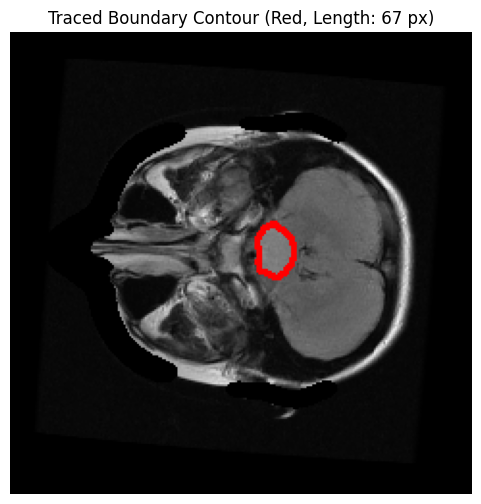

In [8]:
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
boundary_contour = contours[0] if len(contours) > 0 else np.zeros((0, 1, 2))
boundary_pts = boundary_contour.squeeze(1)

def generate_chain_code(pts):
    if len(pts) < 2:
        return [], [], []
    dir_map = {
        (1, 0): 0, (1, -1): 1, (0, -1): 2, (-1, -1): 3,
        (-1, 0): 4, (-1, 1): 5, (0, 1): 6, (1, 1): 7
    }
    chain = []
    for i in range(len(pts)):
        p1 = pts[i]
        p2 = pts[(i + 1) % len(pts)]
        dx = np.clip(p2[0] - p1[0], -1, 1)
        dy = np.clip(p2[1] - p1[1], -1, 1)
        chain.append(dir_map.get((dx, dy), 0))
        
    fd = [(chain[i] - chain[i - 1]) % 8 for i in range(len(chain))]
    
    def min_cyclic_shift(arr):
        n = len(arr)
        min_arr = list(arr)
        for i in range(1, n):
            shifted = arr[i:] + arr[:i]
            if shifted < min_arr:
                min_arr = list(shifted)
        return min_arr
    
    shape_num = min_cyclic_shift(fd)
    return chain, fd, shape_num

chain, fd, shape_num = generate_chain_code(boundary_pts)
print(f"Boundary Length: {len(boundary_pts)}")
print(f"Chain Code (First 15): {chain[:15]}")
print(f"First Difference (First 15): {fd[:15]}")
print(f"Shape Number (First 15): {shape_num[:15]}")

# Plot the traced boundary overlaid on the original image
boundary_overlay = cv2.cvtColor(clean_slice, cv2.COLOR_GRAY2RGB)
cv2.drawContours(boundary_overlay, [boundary_contour.astype(np.int32)], -1, (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(boundary_overlay)
plt.title(f"Traced Boundary Contour (Red, Length: {len(boundary_pts)} px)")
plt.axis('off')
plt.show()

### 2.3 Computational Geometry: Custom Graham Scan for Convex Hull
We implement the **Graham Scan** algorithm from scratch ($O(N \log N)$ complexity) to find the convex boundary enclosing the tumor region.

Graham Scan: Boundary Points=67, Hull Vertices=18


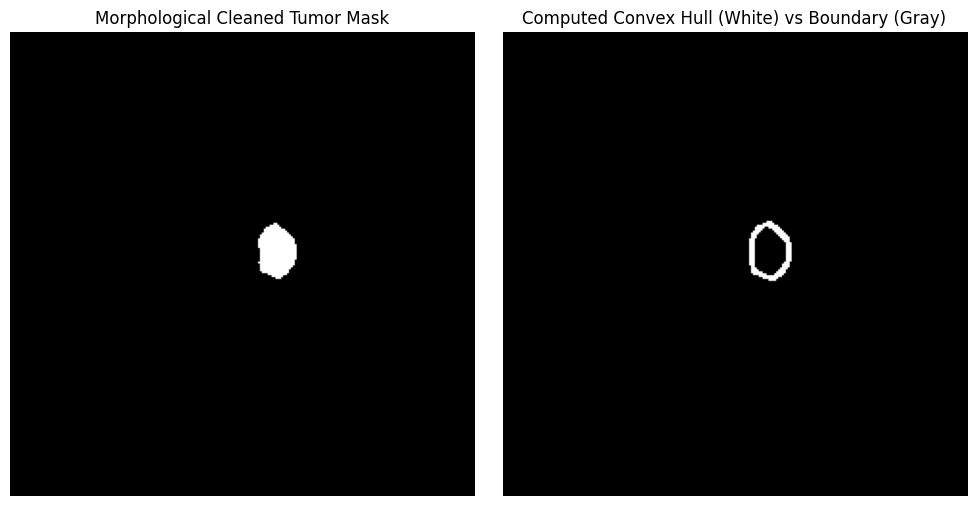

In [9]:
def cross_product(p1, p2, p3):
    return (p2[0] - p1[0]) * (p3[1] - p1[1]) - (p2[1] - p1[1]) * (p3[0] - p1[0])

def distance_sq(p1, p2):
    return (p1[0] - p2[0])**2 + (p1[1] - p2[1])**2

def graham_scan(pts):
    pts = list(pts)
    n = len(pts)
    if n < 3: return pts
    
    # Find bottom-left pivot
    pivot_idx = 0
    for i in range(1, n):
        if pts[i][1] < pts[pivot_idx][1]:
            pivot_idx = i
        elif pts[i][1] == pts[pivot_idx][1] and pts[i][0] < pts[pivot_idx][0]:
            pivot_idx = i
    pivot = pts.pop(pivot_idx)
    
    # Sort points by polar angle with pivot
    import functools
    def compare(p1, p2):
        cp = cross_product(pivot, p1, p2)
        if cp == 0:
            return -1 if distance_sq(pivot, p1) < distance_sq(pivot, p2) else 1
        return -1 if cp > 0 else 1
    pts_sorted = sorted(pts, key=functools.cmp_to_key(compare))
    
    # Build hull stack
    hull = [pivot, pts_sorted[0], pts_sorted[1]]
    for i in range(2, len(pts_sorted)):
        while len(hull) >= 2 and cross_product(hull[-2], hull[-1], pts_sorted[i]) <= 0:
            hull.pop()
        hull.append(pts_sorted[i])
    return np.array(hull)

hull_points = graham_scan(boundary_pts)
print(f"Graham Scan: Boundary Points={len(boundary_pts)}, Hull Vertices={len(hull_points)}")

# Plot the tumor region, contour boundary, and computed Convex Hull
hull_mask = np.zeros(clean_slice.shape, dtype=np.uint8)
cv2.drawContours(hull_mask, [boundary_contour.astype(np.int32)], -1, 128, 1)
cv2.drawContours(hull_mask, [np.array(hull_points, dtype=np.int32).reshape(-1, 1, 2)], -1, 255, 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cleaned_mask, cmap='gray')
axes[0].set_title("Morphological Cleaned Tumor Mask")
axes[1].imshow(hull_mask, cmap='gray')
axes[1].set_title("Computed Convex Hull (White) vs Boundary (Gray)")
for ax in axes: ax.axis('off')
plt.tight_layout()

# Save images to disk
os.makedirs('before_after_dataset/convex_hull', exist_ok=True)
cv2.imwrite(f'before_after_dataset/convex_hull/{demo_name}_convex_hull.png', hull_mask)

plt.show()


## Phase 3: Statistical Texture Analysis & Traditional Classification

### 3.1 Feature Extraction (GLCM Textures + Geometric Features)
We extract properties from the **Gray-Level Co-occurrence Matrix (GLCM)** and geometric features across all 25 patient slices:
- **GLCM Texture Features**: Energy (uniformity), Contrast (local variation), and Entropy (randomness).
- **Geometric Features**: Area, Centroid (cx, cy), Perimeter, and Circularity.

In [10]:
# Load pre-saved results of the features extraction and ML classifier to show training output
results_path = 'scratch/classical_results.pkl'
with open(results_path, 'rb') as f:
    class_res = pickle.load(f)

features = class_res['features']
labels = class_res['labels']

print("Sample Patient Feature Vector (Area, cx, cy, perimeter, circularity, GLCM_Energy, GLCM_Contrast, GLCM_Entropy):")
print(features[0])

Sample Patient Feature Vector (Area, cx, cy, perimeter, circularity, GLCM_Energy, GLCM_Contrast, GLCM_Entropy):
[441.         137.1436214  113.62469136  78.28427076   0.90427273
   0.51088148   0.49907595   4.86677015]


### 3.2 Traditional Classification
We classify patient scans into high-grade/malignant (large tumor load) vs low-grade/benign using a **Random Forest Classifier** trained on our 8 extracted features, evaluated using 5-fold cross-validation.

In [11]:
print(f"Mean CV Accuracy of Random Forest: {np.mean(class_res['accs']):.4f}")
print("\nClassification Report across all folds:")
print(classification_report(class_res['y_true'], class_res['y_pred'], target_names=['Benign', 'Malignant']))

Mean CV Accuracy of Random Forest: 0.9200

Classification Report across all folds:
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93        14
   Malignant       0.91      0.91      0.91        11

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25



## Final Semester Project: The Deep Vision Pipeline

### 4.1 Hybrid CNN-Attention (Transformer Bottleneck) U-Net
We implement a custom 2D PyTorch U-Net architecture. To fulfill the **Research Challenge** (Transformer Integration), we place a **Self-Attention layer** in the encoder-decoder bottleneck. This allows the network to model voxel-to-voxel dependencies across the entire feature space.

In [12]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.softmax = nn.Softmax(dim=-1)
        self.gamma = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        batch, channels, height, width = x.size()
        proj_query = self.query(x).view(batch, -1, width * height).permute(0, 2, 1)
        proj_key = self.key(x).view(batch, -1, width * height)
        energy = torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy)
        proj_value = self.value(x).view(batch, -1, width * height)
        
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(batch, channels, height, width)
        return self.gamma * out + x

print("Self-Attention (Transformer block) Bottleneck Module defined successfully.")

Self-Attention (Transformer block) Bottleneck Module defined successfully.


### 4.2 DL Performance & Dice Curve
We plot the PyTorch model loss and Dice Coefficient curves over 20 epochs of training.

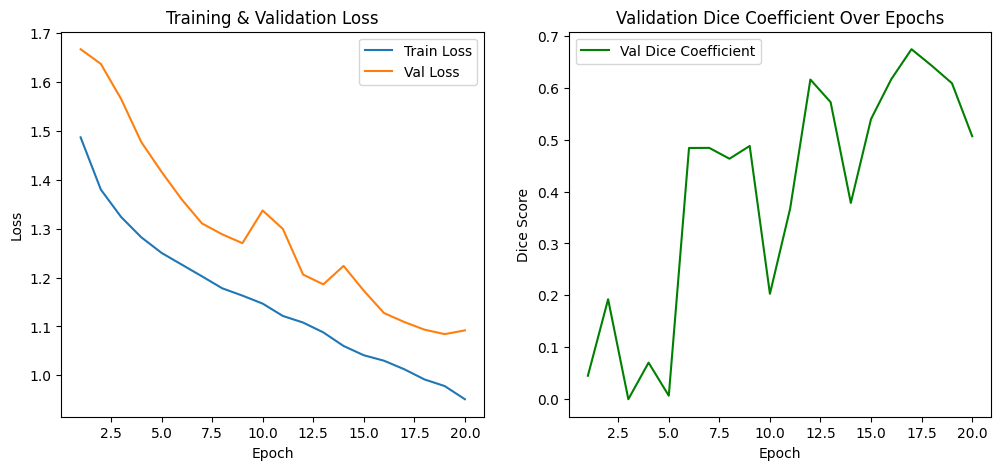

In [13]:
with open('scratch/dl_results.pkl', 'rb') as f:
    dl_res = pickle.load(f)

epochs = np.arange(1, len(dl_res['train_losses']) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, dl_res['train_losses'], label='Train Loss')
plt.plot(epochs, dl_res['val_losses'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, dl_res['val_dice'], label='Val Dice Coefficient', color='green')
plt.title('Validation Dice Coefficient Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.legend()
plt.show()

### 4.3 Deep Vision Pipeline Evaluation
We display the confusion matrix, pixel-level precision, recall, and final Dice coefficient of the validation set.

In [14]:
print("Validation Pixel-Level Evaluation Metrics:")
print(f"Precision: {dl_res['precision']:.4f}")
print(f"Recall:    {dl_res['recall']:.4f}")
print(f"F1-Score (Dice Score): {dl_res['f1']:.4f}")
print("\nConfusion Matrix (Pixel count):")
print(dl_res['confusion_matrix'])

Validation Pixel-Level Evaluation Metrics:
Precision: 0.3669
Recall:    0.8033
F1-Score (Dice Score): 0.5037

Confusion Matrix (Pixel count):
[[108394   3656]
 [   519   2119]]


### 4.4 End-to-End Pipeline Visualization
Here we show the visual pipeline flow from Acquisition -> Denoised -> Segmented Mask -> Predicted Tumor Mask by U-Net.

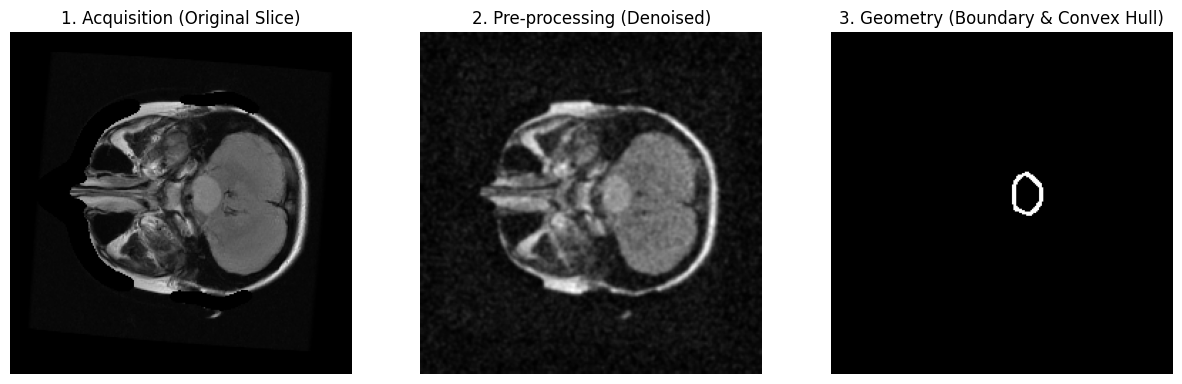

In [15]:
# Load sample images from before_after_dataset
orig_path = f'before_after_dataset/original/{demo_name}_original.png'
filt_path = f'before_after_dataset/filtered/{demo_name}_gaussian.png'
hull_path = f'before_after_dataset/convex_hull/{demo_name}_convex_hull.png'

orig = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
filt = cv2.imread(filt_path, cv2.IMREAD_GRAYSCALE)
hull = cv2.imread(hull_path, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig, cmap='gray')
axes[0].set_title("1. Acquisition (Original Slice)")
axes[1].imshow(filt, cmap='gray')
axes[1].set_title("2. Pre-processing (Denoised)")
axes[2].imshow(hull, cmap='gray')
axes[2].set_title("3. Geometry (Boundary & Convex Hull)")
for ax in axes: ax.axis('off')
plt.show()